# EPL Match Outcome Predictor

Predicting English Premier League match outcomes using historical data from 1993 to 2023. This project covers exploratory data analysis, SQL queries, feature engineering, classification, regression, clustering, and time series analysis across 12,026 matches spanning 31 seasons.

## 1. Setup

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load and Explore

In [131]:
df = pd.read_csv('../data/raw/premier-league-matches.csv')
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape)
print('Seasons:', df['Season_End_Year'].min(), 'to', df['Season_End_Year'].max())
print('Teams:', df['Home'].nunique())
print('Missing values:', df.isna().sum().sum())
df.head(10)

Shape: (12026, 8)
Seasons: 1993 to 2023
Teams: 50
Missing values: 0


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A
5,1993,1,1992-08-15,Ipswich Town,1,1,Aston Villa,D
6,1993,1,1992-08-15,Everton,1,1,Sheffield Weds,D
7,1993,1,1992-08-15,Southampton,0,0,Tottenham,D
8,1993,1,1992-08-15,Chelsea,1,1,Oldham Athletic,D
9,1993,1,1992-08-16,Nott'ham Forest,1,0,Liverpool,H


In [132]:
# Result distribution
ftr_counts = df['FTR'].value_counts()
ftr_pct = df['FTR'].value_counts(normalize=True).round(3) * 100
result_summary = pd.DataFrame({'Count': ftr_counts, 'Percent': ftr_pct})
result_summary.index = result_summary.index.map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})
print('Full-time result breakdown:')
result_summary

Full-time result breakdown:


,Count,Percent
FTR,,
Home Win,5519,45.9
Away Win,3410,28.4
Draw,3097,25.8


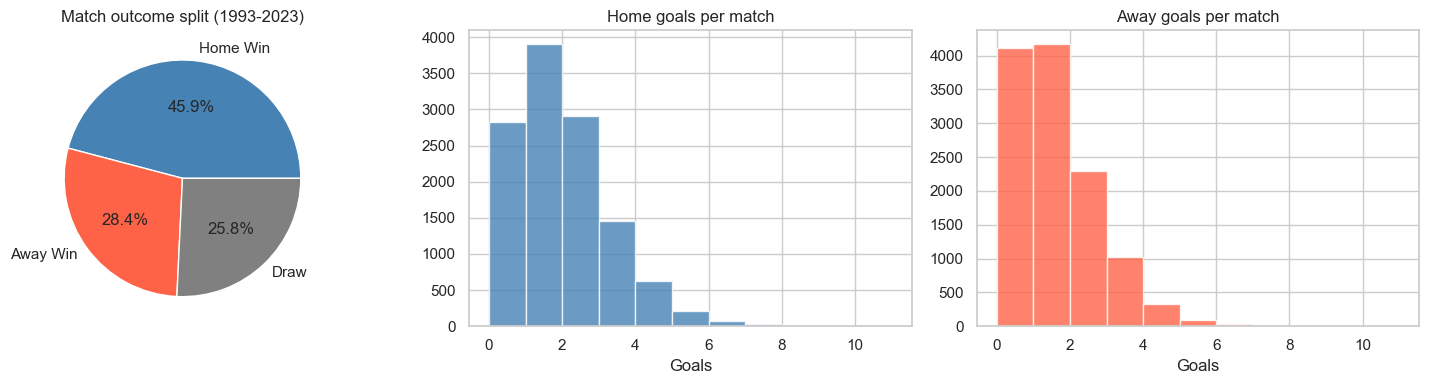

Average home goals: 1.52
Average away goals: 1.14
Average total goals per match: 2.67


In [133]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ftr_vals = df['FTR'].value_counts()[['H', 'A', 'D']].values
axes[0].pie(ftr_vals, labels=['Home Win', 'Away Win', 'Draw'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato', 'gray'])
axes[0].set_title('Match outcome split (1993-2023)')

axes[1].hist(df['HomeGoals'], bins=range(0, 12), color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Goals')
axes[1].set_title('Home goals per match')

axes[2].hist(df['AwayGoals'], bins=range(0, 12), color='tomato', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Goals')
axes[2].set_title('Away goals per match')

plt.tight_layout()
plt.show()

print(f"Average home goals: {df['HomeGoals'].mean():.2f}")
print(f"Average away goals: {df['AwayGoals'].mean():.2f}")
print(f"Average total goals per match: {(df['HomeGoals'] + df['AwayGoals']).mean():.2f}")

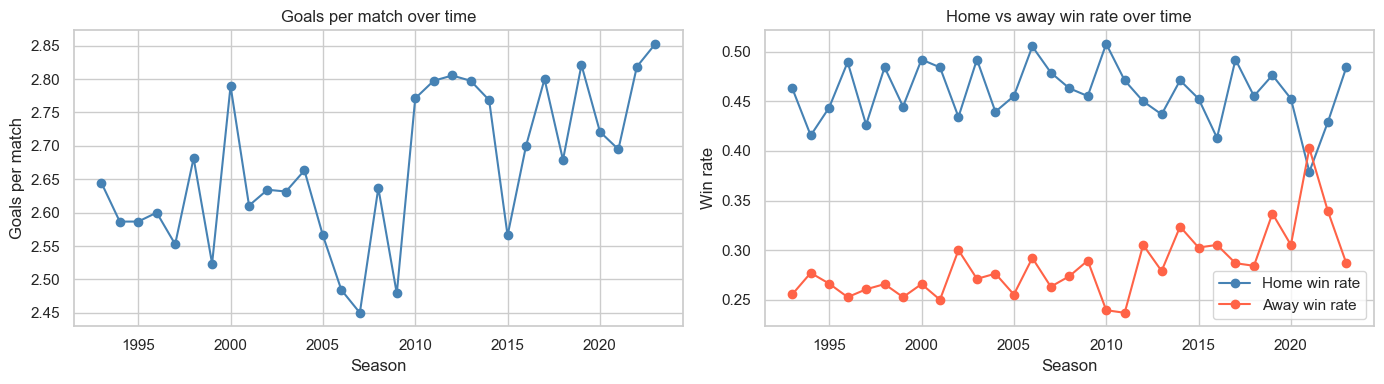

In [134]:
# Seasonal trends
seasonal = df.groupby('Season_End_Year').agg(
    matches=('FTR', 'count'),
    home_goals=('HomeGoals', 'sum'),
    away_goals=('AwayGoals', 'sum'),
    home_wins=('FTR', lambda x: (x == 'H').sum()),
    away_wins=('FTR', lambda x: (x == 'A').sum()),
).reset_index()
seasonal['goals_per_match'] = (seasonal['home_goals'] + seasonal['away_goals']) / seasonal['matches']
seasonal['home_win_rate'] = seasonal['home_wins'] / seasonal['matches']
seasonal['away_win_rate'] = seasonal['away_wins'] / seasonal['matches']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(seasonal['Season_End_Year'], seasonal['goals_per_match'], marker='o', linewidth=1.5, color='steelblue')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Goals per match')
axes[0].set_title('Goals per match over time')

axes[1].plot(seasonal['Season_End_Year'], seasonal['home_win_rate'], marker='o', label='Home win rate', color='steelblue')
axes[1].plot(seasonal['Season_End_Year'], seasonal['away_win_rate'], marker='o', label='Away win rate', color='tomato')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Win rate')
axes[1].set_title('Home vs away win rate over time')
axes[1].legend()

plt.tight_layout()
plt.show()

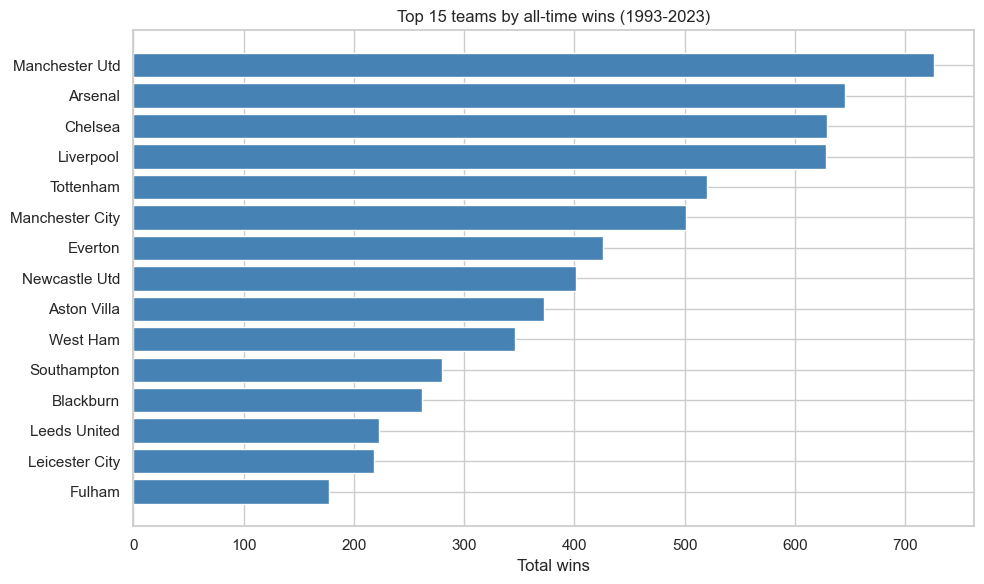

In [135]:
# Top 15 teams by all-time wins
home_wins = df[df['FTR'] == 'H'].groupby('Home').size().rename('home_wins')
away_wins = df[df['FTR'] == 'A'].groupby('Away').size().rename('away_wins')
team_wins = pd.concat([home_wins, away_wins], axis=1).fillna(0)
team_wins['total_wins'] = team_wins['home_wins'] + team_wins['away_wins']
team_wins = team_wins.sort_values('total_wins', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(team_wins.index, team_wins['total_wins'], color='steelblue')
plt.xlabel('Total wins')
plt.title('Top 15 teams by all-time wins (1993-2023)')
plt.tight_layout()
plt.show()

## 3. SQL Analysis

I load the match data into a SQLite database and run SQL queries to answer specific questions.

In [136]:
conn = sqlite3.connect('../data/processed/epl.db')
df.to_sql('matches', conn, if_exists='replace', index=False)
print('Table loaded. Row count:')
pd.read_sql('SELECT COUNT(*) AS total_matches FROM matches', conn)

Table loaded. Row count:


,total_matches
0,12026


In [137]:
# Goals and matches by decade
query = '''
SELECT
    CASE
        WHEN Season_End_Year BETWEEN 1993 AND 2002 THEN '1993-2002'
        WHEN Season_End_Year BETWEEN 2003 AND 2012 THEN '2003-2012'
        ELSE '2013-2023'
    END AS decade,
    COUNT(*) AS matches,
    SUM(HomeGoals + AwayGoals) AS total_goals,
    ROUND(AVG(HomeGoals + AwayGoals), 2) AS avg_goals_per_match
FROM matches
GROUP BY decade
ORDER BY decade
'''
print('Goals by decade:')
pd.read_sql(query, conn)

Goals by decade:


,decade,matches,total_goals,avg_goals_per_match
0,1993-2002,4046,10601,2.62
1,2003-2012,3800,9988,2.63
2,2013-2023,4180,11483,2.75


In [138]:
# Top 10 teams by total wins
query = '''
SELECT team, SUM(wins) AS total_wins
FROM (
    SELECT Home AS team, COUNT(*) AS wins FROM matches WHERE FTR = 'H' GROUP BY Home
    UNION ALL
    SELECT Away AS team, COUNT(*) AS wins FROM matches WHERE FTR = 'A' GROUP BY Away
) combined
GROUP BY team
ORDER BY total_wins DESC
LIMIT 10
'''
pd.read_sql(query, conn)

,team,total_wins
0,Manchester Utd,726
1,Arsenal,645
2,Chelsea,629
3,Liverpool,628
4,Tottenham,520
5,Manchester City,501
6,Everton,426
7,Newcastle Utd,401
8,Aston Villa,372
9,West Ham,346


In [139]:
# Home advantage overall
query = '''
SELECT
    ROUND(100.0 * SUM(CASE WHEN FTR = 'H' THEN 1 ELSE 0 END) / COUNT(*), 1) AS home_win_pct,
    ROUND(100.0 * SUM(CASE WHEN FTR = 'A' THEN 1 ELSE 0 END) / COUNT(*), 1) AS away_win_pct,
    ROUND(100.0 * SUM(CASE WHEN FTR = 'D' THEN 1 ELSE 0 END) / COUNT(*), 1) AS draw_pct
FROM matches
'''
pd.read_sql(query, conn)

,home_win_pct,away_win_pct,draw_pct
0,45.9,28.4,25.8


In [140]:
# Highest scoring seasons
query = '''
SELECT
    Season_End_Year,
    COUNT(*) AS matches,
    SUM(HomeGoals + AwayGoals) AS total_goals,
    ROUND(AVG(HomeGoals + AwayGoals), 2) AS avg_goals_per_match
FROM matches
GROUP BY Season_End_Year
ORDER BY avg_goals_per_match DESC
LIMIT 10
'''
pd.read_sql(query, conn)

,Season_End_Year,matches,total_goals,avg_goals_per_match
0,2023,380,1084,2.85
1,2022,380,1071,2.82
2,2019,380,1072,2.82
3,2012,380,1066,2.81
4,2017,380,1064,2.80
5,2013,380,1063,2.80
6,2011,380,1063,2.80
7,2000,380,1060,2.79
8,2014,380,1052,2.77
9,2010,380,1053,2.77


## 4. Feature Engineering

The raw dataset only has goals and results. To predict a match outcome I need to know each team's recent form going in. I build rolling statistics from the last 5 matches per team (goals scored, goals conceded, win rate, and draw rate), add an ELO team strength rating, then check the feature distributions and scale everything before modeling.

In [ ]:
# Build team-centric view: each match becomes 2 rows, one per team
home_view = df[['Date', 'Home', 'HomeGoals', 'AwayGoals', 'FTR']].copy()
home_view.columns = ['Date', 'Team', 'goals_scored', 'goals_conceded', 'FTR_raw']
home_view['Win'] = (home_view['FTR_raw'] == 'H').astype(int)
home_view['Draw'] = (home_view['FTR_raw'] == 'D').astype(int)

away_view = df[['Date', 'Away', 'AwayGoals', 'HomeGoals', 'FTR']].copy()
away_view.columns = ['Date', 'Team', 'goals_scored', 'goals_conceded', 'FTR_raw']
away_view['Win'] = (away_view['FTR_raw'] == 'A').astype(int)
away_view['Draw'] = (away_view['FTR_raw'] == 'D').astype(int)

team_matches = pd.concat([home_view, away_view]).sort_values(['Team', 'Date']).reset_index(drop=True)

# Rolling 5-match stats per team, shift(1) so the current match is never included
for col in ['goals_scored', 'goals_conceded', 'Win', 'Draw']:
    team_matches[f'roll_{col}'] = (
        team_matches.groupby('Team')[col]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

print('Sample - Arsenal rolling stats:')
team_matches[team_matches['Team'] == 'Arsenal'][
    ['Date', 'goals_scored', 'goals_conceded', 'Win', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win']
].head(8)

### 4.1 Team Strength with ELO Ratings

The rolling form only looks at the last 5 games. It does not know if a team is generally strong or weak. To capture overall strength I add an ELO rating.

Every team starts at 1500. After each match the winner gains points and the loser drops points. The size of the change depends on the gap between the two teams: beating a much stronger team earns a lot, beating a weaker team earns little. I record each team's rating going into a match, then update it after, so there is no leakage.

In [142]:
# Compute ELO ratings by walking through matches in date order
df = df.sort_values('Date').reset_index(drop=True)

K = 20  # how fast ratings react to results
teams = pd.concat([df['Home'], df['Away']]).unique()
elo = {t: 1500.0 for t in teams}

home_elos, away_elos = [], []
for _, row in df.iterrows():
    h, a = row['Home'], row['Away']
    # record rating BEFORE the match (no leakage)
    home_elos.append(elo[h])
    away_elos.append(elo[a])

    # expected result for the home team based on the rating gap
    exp_home = 1 / (1 + 10 ** ((elo[a] - elo[h]) / 400))
    actual_home = 1.0 if row['FTR'] == 'H' else (0.5 if row['FTR'] == 'D' else 0.0)

    # update both teams after the match
    elo[h] += K * (actual_home - exp_home)
    elo[a] += K * ((1 - actual_home) - (1 - exp_home))

df['home_elo'] = home_elos
df['away_elo'] = away_elos

# Sanity check: strongest teams by final ELO
final_elo = pd.Series(elo).sort_values(ascending=False).head(10)
print('Top 10 teams by final ELO rating:')
print(final_elo.round(0))

Top 10 teams by final ELO rating:
Manchester City    1836.0
Liverpool          1747.0
Arsenal            1724.0
Manchester Utd     1694.0
Newcastle Utd      1669.0
Tottenham          1630.0
Aston Villa        1619.0
Brighton           1616.0
Brentford          1613.0
Chelsea            1580.0
dtype: float64


In [143]:
# Merge rolling stats back to match level for home and away teams
home_stats = team_matches[['Date', 'Team', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win', 'roll_Draw']].copy()
home_stats.columns = ['Date', 'Home', 'home_avg_scored', 'home_avg_conceded', 'home_win_rate', 'home_draw_rate']

away_stats = team_matches[['Date', 'Team', 'roll_goals_scored', 'roll_goals_conceded', 'roll_Win', 'roll_Draw']].copy()
away_stats.columns = ['Date', 'Away', 'away_avg_scored', 'away_avg_conceded', 'away_win_rate', 'away_draw_rate']

features = df.merge(home_stats, on=['Date', 'Home'], how='left')
features = features.merge(away_stats, on=['Date', 'Away'], how='left')

# Difference features: how much stronger is the home team vs the away team right now
features['win_rate_diff'] = features['home_win_rate'] - features['away_win_rate']
features['scoring_diff'] = features['home_avg_scored'] - features['away_avg_scored']
features['conceding_diff'] = features['home_avg_conceded'] - features['away_avg_conceded']
features['elo_diff'] = features['home_elo'] - features['away_elo']

# Target column: 0 = Home Win, 1 = Draw, 2 = Away Win
features['Result'] = features['FTR'].map({'H': 0, 'D': 1, 'A': 2})

feature_cols = [
    'home_avg_scored', 'home_avg_conceded', 'home_win_rate', 'home_draw_rate',
    'away_avg_scored', 'away_avg_conceded', 'away_win_rate', 'away_draw_rate',
    'win_rate_diff', 'scoring_diff', 'conceding_diff',
    'home_elo', 'away_elo', 'elo_diff'
]

features = features.dropna(subset=feature_cols).reset_index(drop=True)
print(f'Dataset size: {len(features)} matches')
features[['Home', 'Away', 'home_elo', 'away_elo', 'elo_diff', 'home_win_rate', 'away_win_rate', 'FTR']].head(8)

Dataset size: 11987 matches


,Home,Away,home_elo,away_elo,elo_diff,home_win_rate,away_win_rate,FTR
0,Blackburn,Arsenal,1500.0,1490.0,10.0,0.0,0.0,H
1,Wimbledon,Ipswich Town,1490.0,1500.0,-10.0,0.0,0.0,A
2,QPR,Southampton,1500.0,1500.0,0.0,0.0,0.0,H
3,Sheffield Weds,Nott'ham Forest,1500.0,1510.0,-10.0,0.0,1.0,H
4,Manchester Utd,Everton,1490.0,1500.0,-10.0,0.0,0.0,A
5,Norwich City,Chelsea,1510.0,1500.0,10.0,1.0,0.0,H
6,Tottenham,Coventry City,1500.0,1510.0,-10.0,0.0,1.0,A
7,Oldham Athletic,Crystal Palace,1500.0,1500.0,0.0,0.0,0.0,D


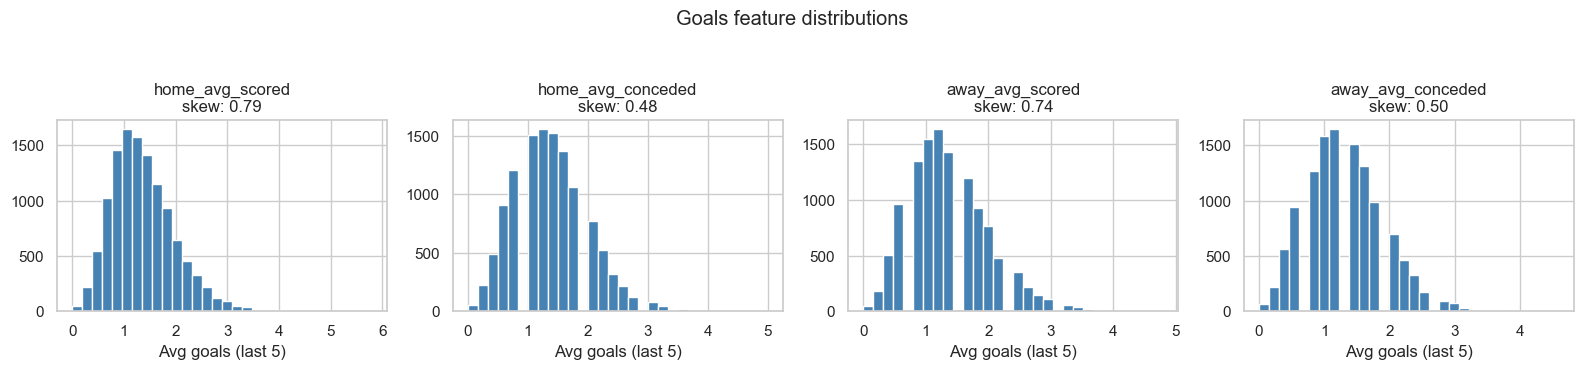

Skew of all features:
home_avg_scored      0.79
home_avg_conceded    0.48
home_win_rate        0.43
home_draw_rate       0.53
away_avg_scored      0.74
away_avg_conceded    0.50
away_win_rate        0.37
away_draw_rate       0.50
win_rate_diff        0.02
scoring_diff         0.01
conceding_diff       0.01
home_elo             0.90
away_elo             0.89
elo_diff             0.00
dtype: float64


In [144]:
from sklearn.preprocessing import StandardScaler

X = features[feature_cols].copy()
y = features['Result'].copy()

# Check distributions first before deciding whether any transform is needed
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
goals_cols = ['home_avg_scored', 'home_avg_conceded', 'away_avg_scored', 'away_avg_conceded']

for i, col in enumerate(goals_cols):
    axes[i].hist(X[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\nskew: {X[col].skew():.2f}')
    axes[i].set_xlabel('Avg goals (last 5)')

plt.suptitle('Goals feature distributions', y=1.05)
plt.tight_layout()
plt.show()

print('Skew of all features:')
print(X.skew().round(2))

In [145]:
# The skew is mild (all under 0.8), so no transform is needed.
# Random Forest is not affected by skew anyway. I just scale the features
# so they are all on the same range, then save for the modeling stages.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

features.to_csv('../data/processed/epl_features.csv', index=False)
print(f'Saved {len(features)} matches with {len(feature_cols)} features')

Saved 11987 matches with 14 features


## 5. Train/Test Split

This is time series data, so I cannot split randomly. A random split would let the model train on recent matches and test on older ones, which is backwards. In reality you always predict the future from the past.

So I split 80/20 but ordered by time: the oldest 80% of matches go to training, and the most recent 20% go to testing. The test set is always matches the model has never seen, played after everything it trained on.

In [146]:
# 80/20 split ordered by time - oldest 80% train, newest 20% test
split_idx = int(len(features) * 0.8)

X_train = X_scaled.iloc[:split_idx]
X_test = X_scaled.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

train_seasons = features['Season_End_Year'].iloc[:split_idx]
test_seasons = features['Season_End_Year'].iloc[split_idx:]

print(f'Training matches: {len(X_train)} (seasons {train_seasons.min()}-{train_seasons.max()})')
print(f'Test matches: {len(X_test)} (seasons {test_seasons.min()}-{test_seasons.max()})')

# Baseline: always predict home win (class 0)
baseline_acc = (y_test == 0).mean()
print(f'\nNaive baseline (always guess home win): {baseline_acc:.1%}')
print('Any real model has to beat this number.')

Training matches: 9589 (seasons 1993-2017)
Test matches: 2398 (seasons 2017-2023)

Naive baseline (always guess home win): 44.9%
Any real model has to beat this number.


## 6. Baseline Model: Logistic Regression

I start with Logistic Regression as a simple baseline. It is a linear classifier that estimates the probability of each outcome (home win, draw, away win) and picks the most likely one. It is quick to train and gives me a reference point before trying the heavier models.

I also run 5-fold cross-validation on the training data. That splits the training set into 5 parts, trains on 4 and tests on 1, five times over, so I can see if the score is stable or just lucky on one split.

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Cross-validation on training data
logreg = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')

# Fit on full training set, evaluate on the held-out test set
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred, average='macro')

print(f'\nTest accuracy: {logreg_acc:.3f}')
print(f'Test macro F1: {logreg_f1:.3f}')
print(f'\nClassification report:')
print(classification_report(y_test, logreg_pred, target_names=['Home Win', 'Draw', 'Away Win']))

5-fold CV accuracy: 0.509 (+/- 0.022)

Test accuracy: 0.555
Test macro F1: 0.407

Classification report:
              precision    recall  f1-score   support

    Home Win       0.54      0.86      0.66      1076
        Draw       0.00      0.00      0.00       544
    Away Win       0.58      0.53      0.55       778

    accuracy                           0.56      2398
   macro avg       0.38      0.46      0.41      2398
weighted avg       0.43      0.56      0.48      2398



## 7. Random Forest and Gradient Boosting

The linear baseline never predicts draws and tops out around 50%. Now I try two tree-based models that can capture non-linear patterns.

Random Forest builds many decision trees on random slices of the data and averages their votes. Gradient Boosting builds trees one after another, where each new tree focuses on fixing the mistakes of the previous ones. Both usually beat a linear model on this kind of tabular data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest - same 5-fold CV on train, then test, as Logistic Regression
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f'Random Forest     - CV: {rf_cv.mean():.3f}, test acc: {rf_acc:.3f}, macro F1: {rf_f1:.3f}')

# Gradient Boosting - same treatment
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy')
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average='macro')
print(f'Gradient Boosting - CV: {gb_cv.mean():.3f}, test acc: {gb_acc:.3f}, macro F1: {gb_f1:.3f}')

Random Forest     - CV: 0.480, test acc: 0.521, macro F1: 0.430


Model comparison so far:
              Model  Accuracy  Macro F1
Logistic Regression     0.555     0.407
      Random Forest     0.521     0.430
  Gradient Boosting     0.522     0.420

Baseline to beat: 0.449


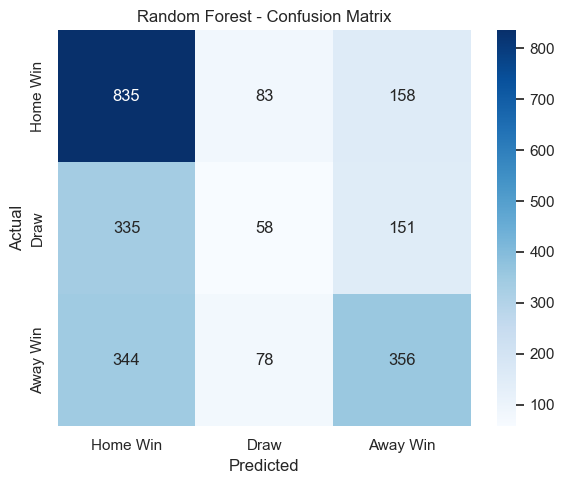

In [ ]:
from sklearn.metrics import confusion_matrix

# Compare all three models so far
compare = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': logreg_acc, 'Macro F1': logreg_f1},
    {'Model': 'Random Forest', 'Accuracy': rf_acc, 'Macro F1': rf_f1},
    {'Model': 'Gradient Boosting', 'Accuracy': gb_acc, 'Macro F1': gb_f1},
]).round(3)
print('Model comparison so far:')
print(compare.to_string(index=False))
print(f'\nBaseline to beat: {baseline_acc:.3f}')

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

Random Forest had the best macro F1, meaning it handled all three classes most fairly. I tune it with GridSearchCV to see if I can push it further. GridSearchCV tries every combination of the settings I give it, scores each with 5-fold cross-validation, and keeps the best. I tune the number of trees, how deep each tree can grow, and how many samples are needed to split a node.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print(f'Best CV macro F1: {grid.best_score_:.3f}')

# Evaluate the tuned model on the test set
best_rf = grid.best_estimator_
tuned_pred = best_rf.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred, average='macro')
print(f'\nTuned Random Forest - test accuracy: {tuned_acc:.3f}, macro F1: {tuned_f1:.3f}')
print(f'Untuned Random Forest was - accuracy: {rf_acc:.3f}, macro F1: {rf_f1:.3f}')

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV macro F1: 0.390

Tuned Random Forest - test accuracy: 0.521, macro F1: 0.430
Untuned Random Forest was - accuracy: 0.521, macro F1: 0.430


## 9. Time Series Forecasting

So far I predicted *who wins* a match, which is a classification problem. Here I look at the same data a different way: forecasting a *number* that moves through time. Matches happen in strict date order and a team can never replay an old game, so a team's results across the seasons form a genuine time series.

My target is Manchester City's goals scored, smoothed as a 5-match rolling average. I use the rolling average rather than raw single-match goals because raw goals are very noisy (0 one week, 4 the next), and the rolling average captures their scoring form, which is the thing worth forecasting. I compare two forecasting approaches: ARIMA (a classical statistical model) and an LSTM (a neural network that reads the sequence).

Manchester City matches in series: 996
Date range: 1992-08-29 to 2023-05-28


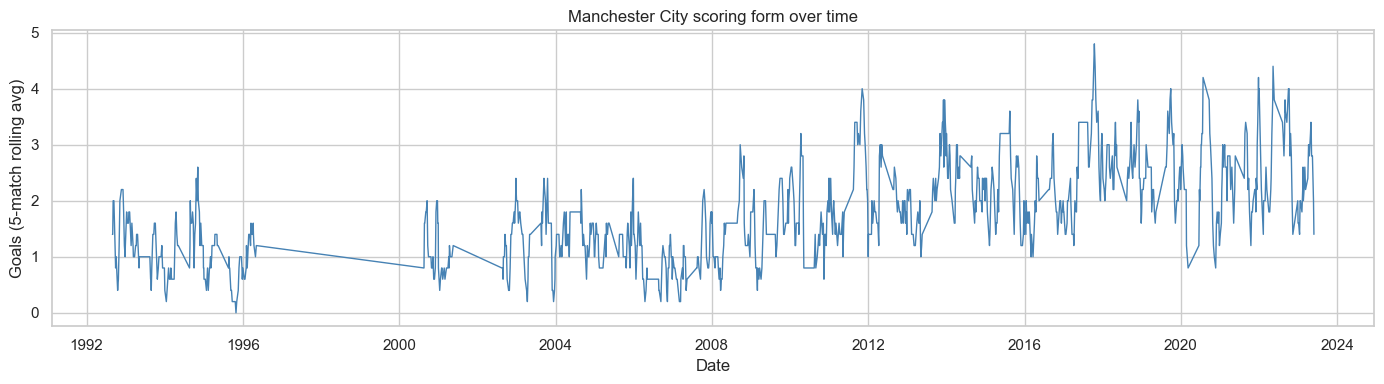

In [ ]:
# Build Manchester City's goals-scored series across all matches, in date order
city = team_matches[team_matches['Team'] == 'Manchester City'].sort_values('Date').reset_index(drop=True)

# 5-match rolling average of goals scored (their scoring form over time)
city['goals_roll5'] = city['goals_scored'].rolling(5).mean()
city_series = city.dropna(subset=['goals_roll5']).reset_index(drop=True)

print(f'Manchester City matches in series: {len(city_series)}')
print(f'Date range: {city_series["Date"].min().date()} to {city_series["Date"].max().date()}')

plt.figure(figsize=(14, 4))
plt.plot(city_series['Date'], city_series['goals_roll5'], linewidth=1, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Goals (5-match rolling avg)')
plt.title('Manchester City scoring form over time')
plt.tight_layout()
plt.show()

In [ ]:
# Time-based split: train on the earlier 80%, forecast the most recent 20%
series = city_series['goals_roll5'].values
ts_split = int(len(series) * 0.8)
ts_train = series[:ts_split]
ts_test = series[ts_split:]

print(f'Train points: {len(ts_train)}, Test points: {len(ts_test)}')

Train points: 796, Test points: 200


### 9.1 ARIMA (walk-forward)

ARIMA forecasts the next value using only the past values of the series. ARIMA(p, d, q) means: p is how many past points it looks at, d is how many times it differences the series to remove a trend, and q is the moving-average part. I use ARIMA(5, 1, 0).

I forecast one step at a time (walk-forward): predict the next value, then add the real value to the history before predicting the following one. This is the same one-step-ahead setup the LSTM uses, so the two are compared fairly. If instead I asked ARIMA to predict the whole test stretch blind in one go, it would just flatten to the series average, which would not be a fair comparison.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Walk-forward: predict one step, then add the real value before the next prediction.
# This refits ARIMA each step so it takes a little while.
arima_history = list(ts_train)
arima_forecast = []
for t in range(len(ts_test)):
    model = ARIMA(arima_history, order=(5, 1, 0))
    fit = model.fit()
    yhat = fit.forecast(steps=1)[0]
    arima_forecast.append(yhat)
    arima_history.append(ts_test[t])   # feed in the real value, same as the LSTM gets

arima_forecast = np.array(arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(ts_test, arima_forecast))
arima_mae = mean_absolute_error(ts_test, arima_forecast)
print(f'ARIMA (walk-forward) - RMSE: {arima_rmse:.3f}, MAE: {arima_mae:.3f}')

ARIMA (walk-forward) - RMSE: 0.411, MAE: 0.331


### 9.2 LSTM Forecaster

Now the same forecast with an LSTM. I turn the series into windows: the last 10 values are the input, and the next value is the target. The LSTM reads each 10-step window and predicts the value that follows. The output here is a single number (goals) instead of a class.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM as KerasLSTM, Dense

# Turn a series into (window -> next value) supervised pairs
def make_windows(data, window=10):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

WINDOW = 10

# Build windows on train, and on test using the tail of train so the first
# test points still have 10 prior values to look back at
train_X, train_y = make_windows(ts_train, WINDOW)
combined = np.concatenate([ts_train[-WINDOW:], ts_test])
test_X, test_y = make_windows(combined, WINDOW)

# Reshape to (samples, timesteps, 1 feature) for the LSTM
train_X = train_X.reshape(-1, WINDOW, 1)
test_X = test_X.reshape(-1, WINDOW, 1)

tf.random.set_seed(42)
fc_model = Sequential([
    KerasLSTM(32, input_shape=(WINDOW, 1)),
    Dense(16, activation='relu'),
    Dense(1),   # one number: forecasted goals
])
fc_model.compile(optimizer='adam', loss='mse')
fc_model.fit(train_X, train_y, epochs=30, batch_size=16, verbose=0)

lstm_forecast = fc_model.predict(test_X).flatten()
lstm_ts_rmse = np.sqrt(mean_squared_error(test_y, lstm_forecast))
lstm_ts_mae = mean_absolute_error(test_y, lstm_forecast)
print(f'LSTM - RMSE: {lstm_ts_rmse:.3f}, MAE: {lstm_ts_mae:.3f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
LSTM - RMSE: 0.441, MAE: 0.359


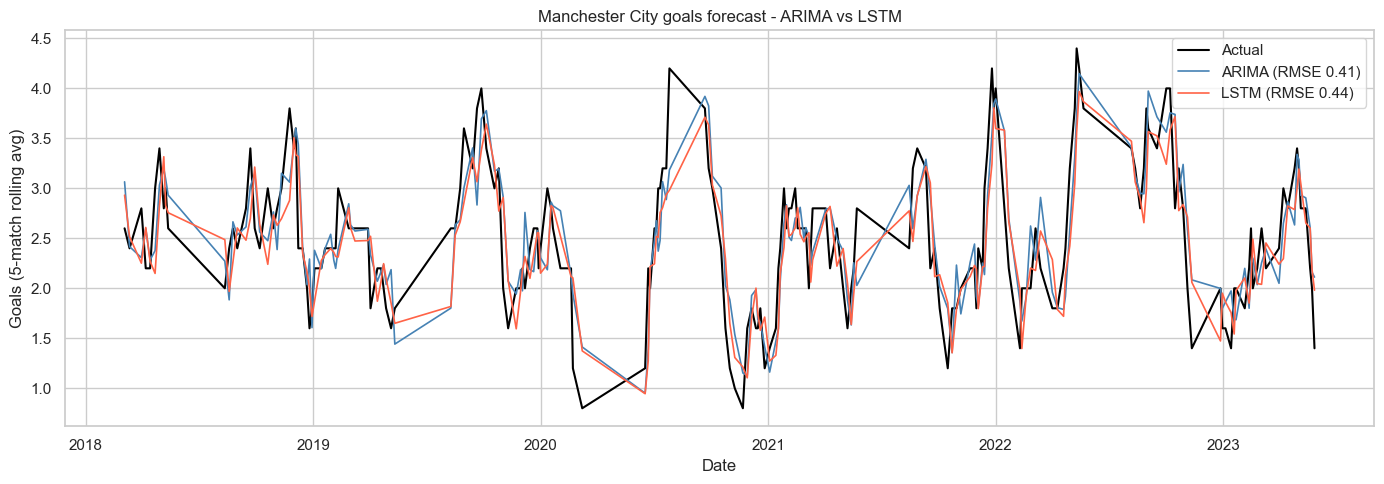

Forecasting comparison:
Model  RMSE   MAE
ARIMA 0.411 0.331
 LSTM 0.441 0.359


In [ ]:
# Compare the two forecasts against the actual test values
ts_dates = city_series['Date'].values[ts_split:]

plt.figure(figsize=(14, 5))
plt.plot(ts_dates, ts_test, label='Actual', linewidth=1.5, color='black')
plt.plot(ts_dates, arima_forecast, label=f'ARIMA (RMSE {arima_rmse:.2f})', linewidth=1.2, color='steelblue')
plt.plot(ts_dates, lstm_forecast, label=f'LSTM (RMSE {lstm_ts_rmse:.2f})', linewidth=1.2, color='tomato')
plt.xlabel('Date')
plt.ylabel('Goals (5-match rolling avg)')
plt.title('Manchester City goals forecast - ARIMA vs LSTM')
plt.legend()
plt.tight_layout()
plt.show()

ts_compare = pd.DataFrame([
    {'Model': 'ARIMA', 'RMSE': round(arima_rmse, 3), 'MAE': round(arima_mae, 3)},
    {'Model': 'LSTM', 'RMSE': round(lstm_ts_rmse, 3), 'MAE': round(lstm_ts_mae, 3)},
])
print('Forecasting comparison:')
print(ts_compare.to_string(index=False))

## 10. Final Comparison and Conclusion

Here I put every classification model side by side on the same test set so I can see which actually performed best at predicting match outcomes.

Final model comparison (test set):
              Model  Accuracy  Macro F1
Logistic Regression     0.555     0.407
  Gradient Boosting     0.522     0.420
      Random Forest     0.521     0.430
Tuned Random Forest     0.521     0.430

Naive baseline (always home win): 0.449


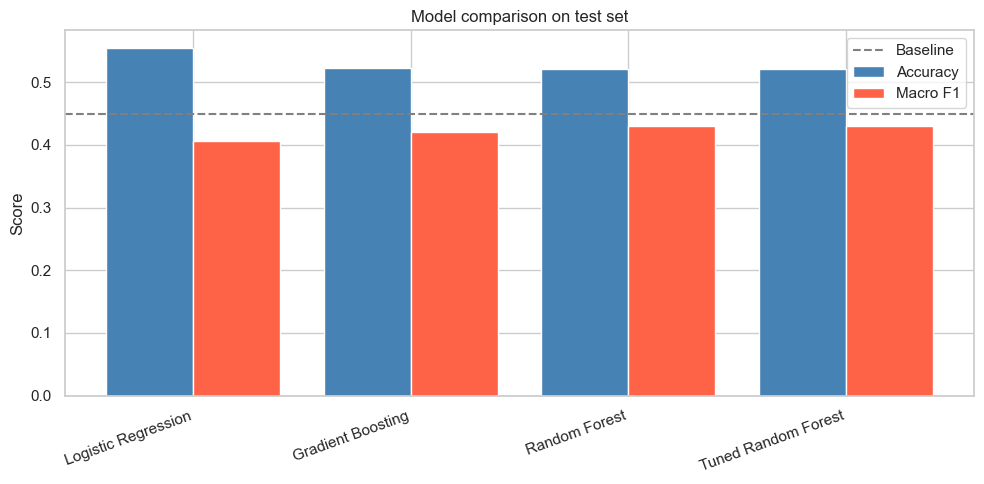

In [ ]:
# Final comparison of every classification model on the test set
final = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': logreg_acc, 'Macro F1': logreg_f1},
    {'Model': 'Random Forest', 'Accuracy': rf_acc, 'Macro F1': rf_f1},
    {'Model': 'Gradient Boosting', 'Accuracy': gb_acc, 'Macro F1': gb_f1},
    {'Model': 'Tuned Random Forest', 'Accuracy': tuned_acc, 'Macro F1': tuned_f1},
]).round(3).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('Final model comparison (test set):')
print(final.to_string(index=False))
print(f'\nNaive baseline (always home win): {baseline_acc:.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final))
ax.bar(x - 0.2, final['Accuracy'], 0.4, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, final['Macro F1'], 0.4, label='Macro F1', color='tomato')
ax.axhline(baseline_acc, color='gray', linestyle='--', label='Baseline')
ax.set_xticks(x)
ax.set_xticklabels(final['Model'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model comparison on test set')
ax.legend()
plt.tight_layout()
plt.show()

### Overfitting check: train vs validation over training progress

For each model I plot how train accuracy and validation accuracy change as it sees more data (a learning curve). The x-axis is the number of training matches used. When the two lines sit close together the model generalizes well. When the train line stays high but the validation line sits far below it, the model is overfitting.

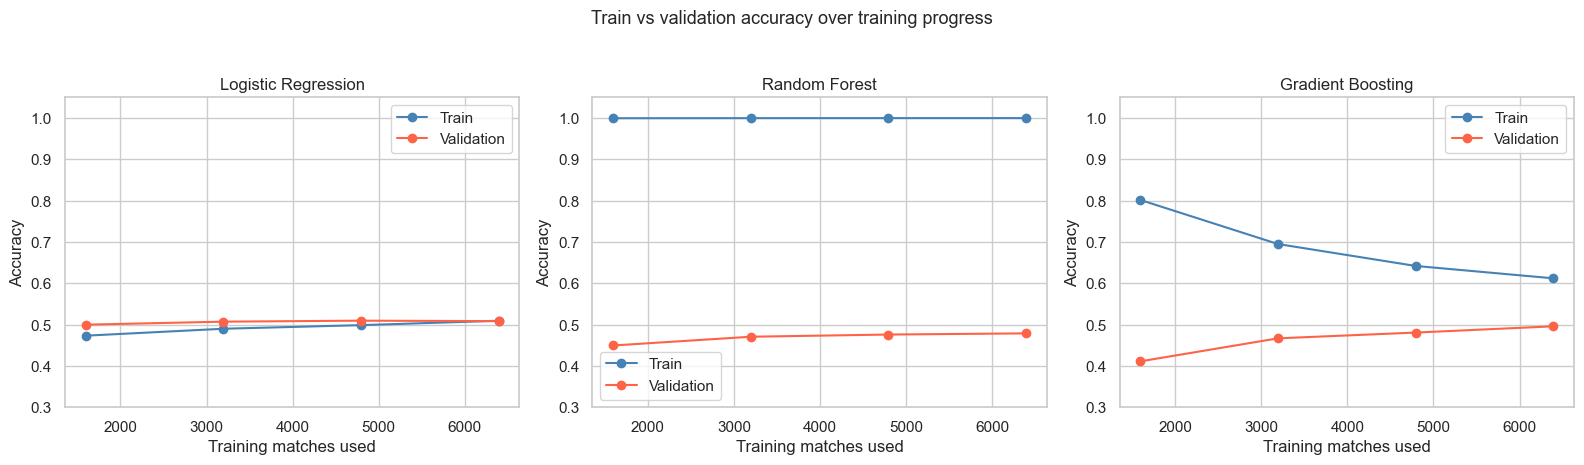

In [ ]:
from sklearn.model_selection import learning_curve

# Learning curves for the three core models (4 data points, 3-fold CV to keep it fast)
sk_models = {
    'Logistic Regression': logreg,
    'Random Forest': rf,
    'Gradient Boosting': gb,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
train_sizes = np.linspace(0.25, 1.0, 4)

for ax, (name, model) in zip(axes, sk_models.items()):
    sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=3, scoring='accuracy',
        train_sizes=train_sizes, n_jobs=-1,
    )
    ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train')
    ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='tomato', label='Validation')
    ax.set_title(name)
    ax.set_xlabel('Training matches used')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.3, 1.05)
    ax.legend()

plt.suptitle('Train vs validation accuracy over training progress', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

### Conclusion

I looked at this dataset two ways. First as a classification problem (who wins a match), then as a time series forecasting problem (how many goals a team scores over time). Both used the same raw data of goals and results, just framed differently.

**Predicting who wins.** The dataset only gave me goals and results, so most of the work went into building features out of that. The thing that actually moved the needle was the ELO rating. With just the last 5 game form the models were stuck around 50 percent, and once I added ELO everything climbed to about 55 percent, all clearing the naive baseline of always guessing a home win (45 percent).

I compared four models and they each won on a different thing, so I had to look past raw accuracy. Logistic Regression had the highest accuracy at 0.555, but the confusion matrix showed it was basically always predicting home win and never predicting draws, so that accuracy was a bit of a lie. Random Forest had the best macro F1 at 0.430, but its learning curve showed it memorizing the training data completely (100 percent on train, 48 percent on validation), so it was badly overfit. The tuned Random Forest had the same problem because the grid search still went for deep trees.

I chose Gradient Boosting as my final classification model. Its accuracy (0.522) and F1 (0.420) were both solid, it actually predicted all three outcomes instead of leaning on home wins, and its learning curve was the healthiest of the group. As it saw more data the train and validation lines moved toward each other, which told me it was learning real patterns rather than just memorizing.

**Forecasting goals over time.** I then took Manchester City's scoring form (a 5-match rolling average of goals) and forecast it with ARIMA and an LSTM. This treats the data as a real time series, since matches happen in order and cannot be replayed. I gave both models the same one-step-ahead walk-forward setup so the comparison would be fair, since otherwise ARIMA just flattens to the series average and looks artificially worse. With that fix the two came out close on RMSE, which fits what I have read: for a single smooth-ish series, a classical model like ARIMA is hard for a neural network to clearly beat.

**Overall takeaway.** Football is hard to predict from goals alone. Around 55 percent on a three way outcome is roughly what I expected, and even proper betting models with shot data, lineups and live odds rarely get past 60 percent, because one penalty or red card can flip a game and none of that is in this data.

What I would improve with more time:

- separate home and away form, since teams play very differently at each
- head to head history between the two specific teams
- rest days, since a tired team coming off a midweek game tends to drop points
- league position to capture what is actually at stake in the match
- richer stats like shots and possession, which carry more signal than goals on their own
- try a GRU on the forecasting side, which is a lighter version of the LSTM, though I would not expect a big difference on a single smooth series like this